**Практика 4**

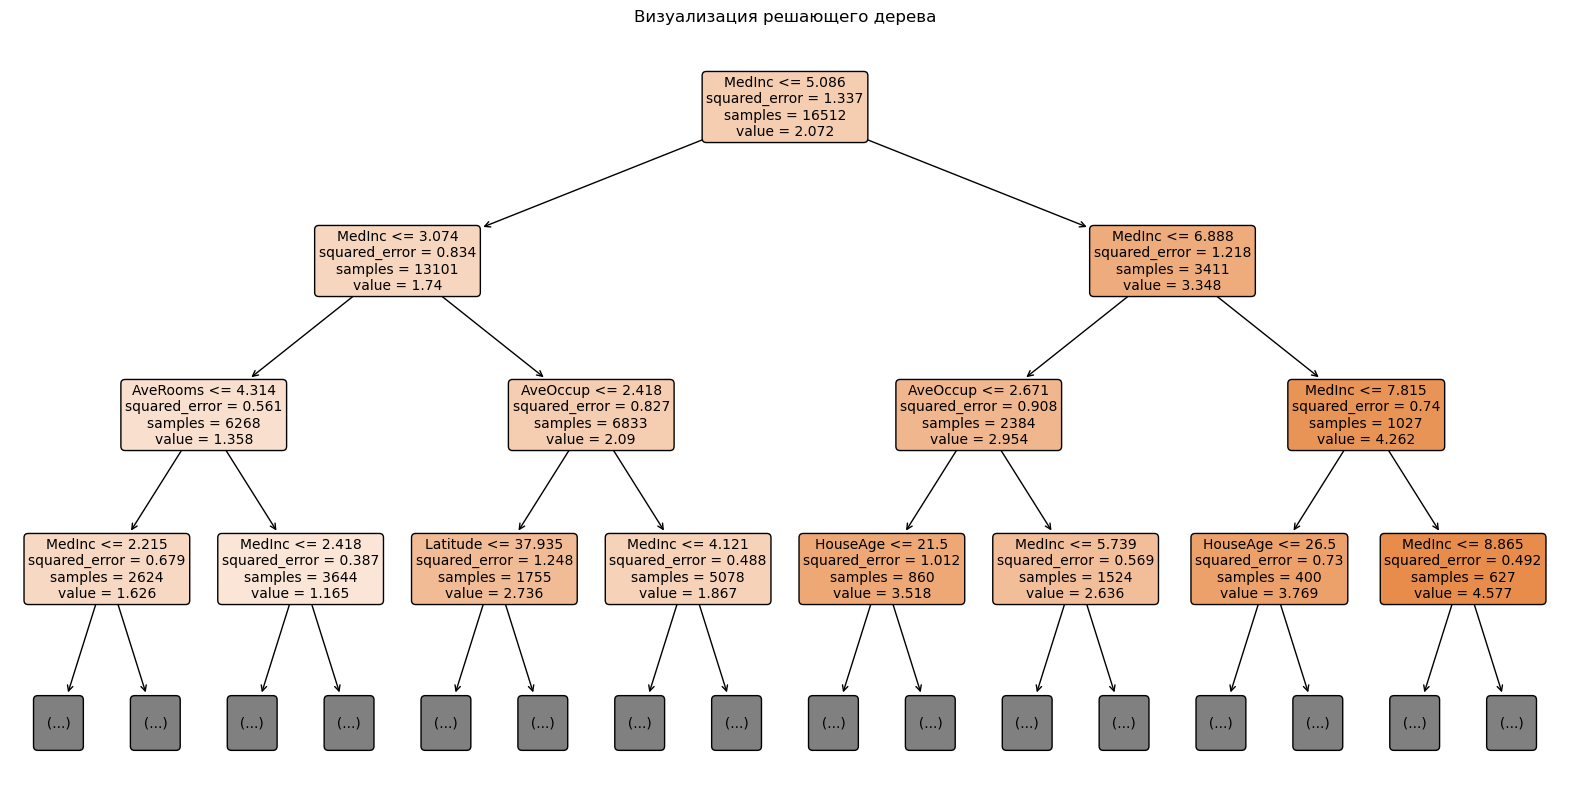

In [5]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.datasets import fetch_california_housing 
from sklearn.model_selection import train_test_split 
from sklearn.metrics import mean_squared_error

X, y = fetch_california_housing(return_X_y = True) 
feature_names = fetch_california_housing().feature_names





X_train , X_test , y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42 )


regresion_tree = DecisionTreeRegressor()
regresion_tree.fit(X_train , y_train)


train_pred = regresion_tree.predict(X_train)

test_pred = regresion_tree.predict(X_test)



mse_train = mean_squared_error(y_train, train_pred)
mse_test = mean_squared_error(y_test, test_pred)

plt.figure(figsize = (20, 10))
plot_tree(regresion_tree, max_depth = 3, filled = True , feature_names = feature_names, rounded = True, fontsize = 10)
plt.title('Визуализация решающего дерева') 

plt.show()


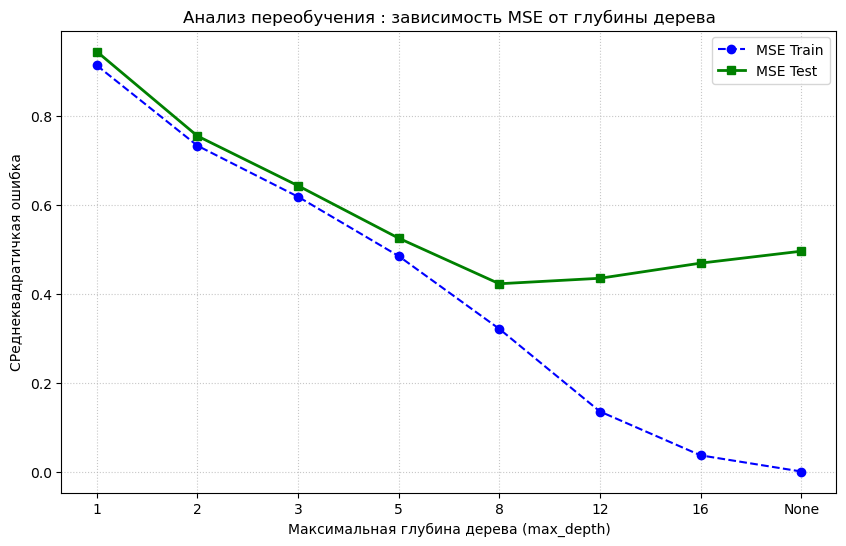

In [6]:
depth = [1,2,3,5,8,12,16,None]

mse_train_list = []
mse_test_list = []

x_labels = [str(i) for i in depth]


for i in depth:
    model = DecisionTreeRegressor(max_depth = i, random_state = 42)
    model.fit(X_train , y_train) 


    mse_train_pred = model.predict(X_train)
    mse_test_pred = model.predict(X_test) 

    mse_train_list.append(mean_squared_error(y_train, mse_train_pred))
    mse_test_list.append(mean_squared_error( y_test,mse_test_pred))

plt.figure(figsize = (10 , 6))
plt.plot(x_labels , mse_train_list , marker = 'o' , label = 'MSE Train', color = 'blue' , linestyle = '--')
plt.plot(x_labels , mse_test_list , marker = 's', label = 'MSE Test' , color = 'green' , linewidth= 2)
plt.xlabel('Максимальная глубина дерева (max_depth)') 
plt.ylabel('СРеднеквадратичкая ошибка') 
plt.title('Анализ переобучения : зависимость MSE от глубины дерева') 
plt.legend()
plt.grid(True , linestyle = ':' , alpha = 0.7)
plt.show()

ТОп 5 самых выжных признаков: 
MedInc       0.662933
AveOccup     0.132096
Latitude     0.061311
Longitude    0.050202
HouseAge     0.042222
dtype: float64


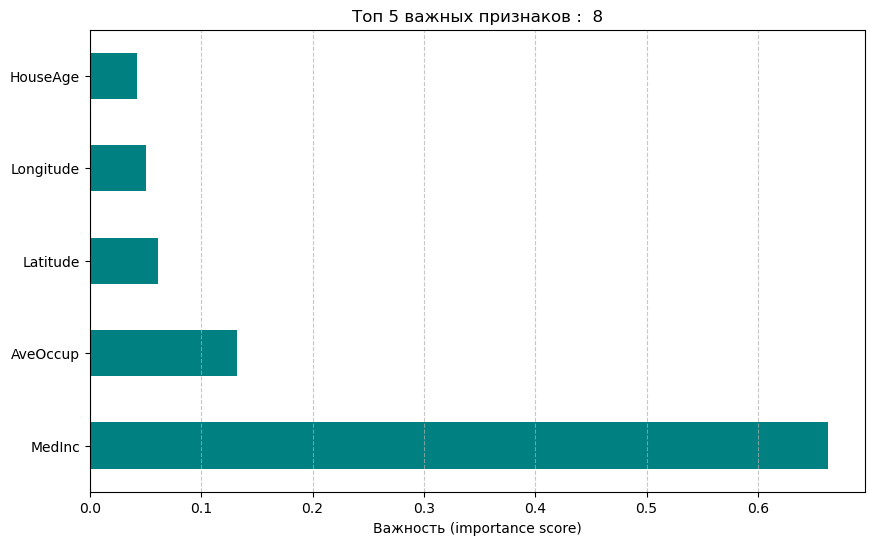

In [7]:
model_new = DecisionTreeRegressor(max_depth = 8 , random_state = 42)
model_new.fit(X_train , y_train)



importance  = model_new.feature_importances_
feature_imp_df = pd.Series(importance , index = feature_names).sort_values(ascending= False) 



best_index = mse_test_list.index(min(mse_test_list))
best_depth = depth[best_index]

print('ТОп 5 самых выжных признаков: ') 
print(feature_imp_df.head())

plt.figure(figsize = (10, 6))
feature_imp_df.head(5).plot(kind='barh', color='teal')
plt.title(f'Топ 5 важных признаков :  {best_depth}') 
plt.xlabel('Важность (importance score)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [8]:
from sklearn.datasets import load_breast_cancer
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split


data = load_breast_cancer()

X_train , X_test , y_train , y_test = train_test_split(data.data , data.target , test_size= 0.2 , random_state = 42)


critery = ['gini' , 'entropy'] 

for c in critery: 
    model =DecisionTreeClassifier(criterion = c, random_state = 42)
    model.fit(X_train, y_train) 

    y_pred = model.predict(X_test) 

    print(f' -- Результаты для критерия : {c} ---')
    print(f'Ассuracy : {accuracy_score(y_test, y_pred):.4f}')
    print(classification_report(y_test, y_pred))
    

 -- Результаты для критерия : gini ---
Ассuracy : 0.9474
              precision    recall  f1-score   support

           0       0.93      0.93      0.93        43
           1       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114

 -- Результаты для критерия : entropy ---
Ассuracy : 0.9474
              precision    recall  f1-score   support

           0       0.97      0.88      0.93        43
           1       0.93      0.99      0.96        71

    accuracy                           0.95       114
   macro avg       0.95      0.93      0.94       114
weighted avg       0.95      0.95      0.95       114



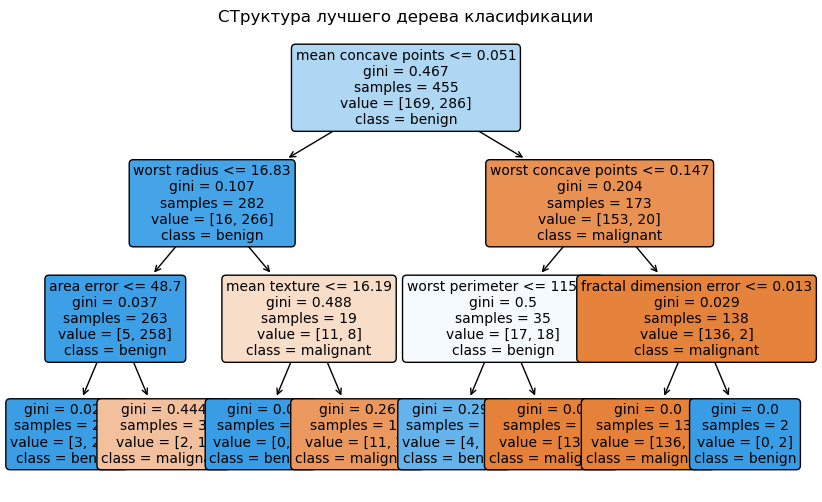

In [9]:
best_model= DecisionTreeClassifier(criterion ='gini' , max_depth = 3 , random_state = 42)
best_model.fit(X_train , y_train) 

plt.figure(figsize = (10 , 6))
plot_tree(best_model , feature_names = data.feature_names,
         class_names = data.target_names,
        filled = True, 
        rounded = True, 
        fontsize = 10)


plt.title('СТруктура лучшего дерева класификации')
plt.show()
